In [1]:
# !pip install kagglehub
# !pip install findspark

In [14]:
import os
import cv2
import json
import torch
import base64
import pyspark
import findspark
import kagglehub
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
from glob import glob as gg
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.sql.types import ArrayType, DoubleType, FloatType, IntegerType, StringType

In [3]:
# spark = SparkSession.builder.appName("JsonExtractor").getOrCreate()

findspark.init()

spark = SparkSession.builder \
    .appName("JsonExtractor") \
    .config("spark.driver.port", "5000")\
    .config("spark.blockManager.port", "4000")\
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .config("spark.driver.maxResultSize", "8g") \
    .getOrCreate()

25/04/16 13:31:56 WARN Utils: Your hostname, victors-MacBook-Air.local resolves to a loopback address: 127.0.0.1, but we couldn't find any external IP address!
25/04/16 13:31:56 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/04/16 13:31:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [6]:
# Local Access

dir = "archive/batch_*/json/kaggle_data_*.json"

json_files = gg(dir)

sorted(json_files)

['archive/batch_1/json/kaggle_data_1.json',
 'archive/batch_10/json/kaggle_data_10.json',
 'archive/batch_2/json/kaggle_data_2.json',
 'archive/batch_3/json/kaggle_data_3.json',
 'archive/batch_4/json/kaggle_data_4.json',
 'archive/batch_5/json/kaggle_data_5.json',
 'archive/batch_6/json/kaggle_data_6.json',
 'archive/batch_7/json/kaggle_data_7.json',
 'archive/batch_8/json/kaggle_data_8.json',
 'archive/batch_9/json/kaggle_data_9.json']

In [ ]:
# Cloud Access

dataset_path = kagglehub.dataset_download("aidapearson/ocr-data")

In [6]:
batches = gg(f"{dataset_path}/*")

print(len(batches))
print(batches)

11
['/root/.cache/kagglehub/datasets/aidapearson/ocr-data/versions/36/batch_10', '/root/.cache/kagglehub/datasets/aidapearson/ocr-data/versions/36/batch_3', '/root/.cache/kagglehub/datasets/aidapearson/ocr-data/versions/36/batch_2', '/root/.cache/kagglehub/datasets/aidapearson/ocr-data/versions/36/batch_1', '/root/.cache/kagglehub/datasets/aidapearson/ocr-data/versions/36/batch_4', '/root/.cache/kagglehub/datasets/aidapearson/ocr-data/versions/36/batch_6', '/root/.cache/kagglehub/datasets/aidapearson/ocr-data/versions/36/batch_5', '/root/.cache/kagglehub/datasets/aidapearson/ocr-data/versions/36/batch_8', '/root/.cache/kagglehub/datasets/aidapearson/ocr-data/versions/36/extras', '/root/.cache/kagglehub/datasets/aidapearson/ocr-data/versions/36/batch_9', '/root/.cache/kagglehub/datasets/aidapearson/ocr-data/versions/36/batch_7']


In [7]:
extras_path = os.path.join(os.path.dirname(batches[0]), "extras")
print(len(batches))
print(extras_path)
if os.path.exists(extras_path):
    extras_index = batches.index(extras_path)
    batches.pop(extras_index)
print(len(batches))

11
/root/.cache/kagglehub/datasets/aidapearson/ocr-data/versions/36/extras
10


In [8]:
batch_files = []

for i in range(len(batches)):
    temp_files = gg(f"{batches[i]}/*")
    temp_files.sort()
    batch_files.append(temp_files)

# batch_files.sort(reverse = True)
print(batch_files)

[['/root/.cache/kagglehub/datasets/aidapearson/ocr-data/versions/36/batch_10/JSON', '/root/.cache/kagglehub/datasets/aidapearson/ocr-data/versions/36/batch_10/background_images'], ['/root/.cache/kagglehub/datasets/aidapearson/ocr-data/versions/36/batch_3/JSON', '/root/.cache/kagglehub/datasets/aidapearson/ocr-data/versions/36/batch_3/background_images'], ['/root/.cache/kagglehub/datasets/aidapearson/ocr-data/versions/36/batch_2/JSON', '/root/.cache/kagglehub/datasets/aidapearson/ocr-data/versions/36/batch_2/background_images'], ['/root/.cache/kagglehub/datasets/aidapearson/ocr-data/versions/36/batch_1/JSON', '/root/.cache/kagglehub/datasets/aidapearson/ocr-data/versions/36/batch_1/background_images'], ['/root/.cache/kagglehub/datasets/aidapearson/ocr-data/versions/36/batch_4/JSON', '/root/.cache/kagglehub/datasets/aidapearson/ocr-data/versions/36/batch_4/background_images'], ['/root/.cache/kagglehub/datasets/aidapearson/ocr-data/versions/36/batch_6/JSON', '/root/.cache/kagglehub/datase

In [9]:
json_files = [gg(f"{batch[0]}/*.json")[0] for batch in batch_files]
# print(json_files)

In [10]:
images = [gg(f"{batch[1]}")[0] for batch in batch_files]

# images

In [11]:
# with open(json_files[1]) as file:
#     data = json.load(file)

# print(data)

In [7]:
image_data = spark.createDataFrame([], schema = spark.read.json(json_files[0]).schema)

for json_file in json_files:
    temp_df = spark.read.json(json_file)
    image_data = image_data.union(temp_df)

In [8]:
# image_data.show(truncate = 50)
# image_data.count()

In [9]:
image_data = image_data.withColumn("full_latex_chars", col("image_data.full_latex_chars").cast(ArrayType(StringType()))). \
                withColumn("visible_latex_chars", col("image_data.visible_latex_chars").cast(ArrayType(StringType()))). \
                withColumn("visible_char_map", col("image_data.visible_char_map").cast(StringType())). \
                withColumn("width", col("image_data.width").cast(FloatType())). \
                withColumn("height", col("image_data.height").cast(FloatType())). \
                withColumn("depth", col("image_data.depth").cast(FloatType())). \
                withColumn("xmins", col("image_data.xmins").cast(ArrayType(DoubleType()))). \
                withColumn("xmaxs", col("image_data.xmaxs").cast(ArrayType(DoubleType()))). \
                withColumn("ymins", col("image_data.ymins").cast(ArrayType(DoubleType()))). \
                withColumn("ymaxs", col("image_data.ymaxs").cast(ArrayType(DoubleType()))). \
                withColumn("xmins_raw", col("image_data.xmins_raw").cast(ArrayType(IntegerType()))). \
                withColumn("xmaxs_raw", col("image_data.xmaxs_raw").cast(ArrayType(IntegerType()))). \
                withColumn("ymins_raw", col("image_data.ymins_raw").cast(ArrayType(IntegerType()))). \
                withColumn("ymaxs_raw", col("image_data.ymaxs_raw").cast(ArrayType(IntegerType()))). \
                withColumn("png_masks", col("image_data.png_masks").cast(ArrayType(StringType())))


In [10]:
image_data.show(5, truncate = 50)

+----------------------------------------+-------+--------------------------------------------------+--------------------------------------------------+---------------------------------+--------------------------------------------------+------------------------------------+--------------------------------------------------+--------------------------------------------------+--------------------------------------------------+------+------+-----+--------------------------------------------------+--------------------------------------------------+--------------------------------------------------+--------------------------------------------------+--------------------------------------------------+--------------------------------------------------+--------------------------------------------------+--------------------------------------------------+--------------------------------------------------+
|                                filename|   font|                                        ima

In [11]:
image_props = image_data.drop("font", "image_data", "unicode_less_curlies", "unicode_str")

In [12]:
image_props.show(10, truncate = 40)

+----------------------------------------+----------------------------------------+------------------------------------+----------------------------------------+----------------------------------------+----------------------------------------+------+------+-----+----------------------------------------+----------------------------------------+----------------------------------------+----------------------------------------+----------------------------------------+----------------------------------------+----------------------------------------+----------------------------------------+----------------------------------------+
|                                filename|                                   latex|                                uuid|                        full_latex_chars|                     visible_latex_chars|                        visible_char_map| width|height|depth|                                   xmins|                                   xmaxs|                      

In [15]:
# image_prop = spark.createDataFrame([],
#                 schema = StructType([
#                     StructField('full_latex_chars', StringType()),
#                     StructField('visible_latex_chars', StringType()),
#                     StructField('visible_char_map', StringType()),
#                     StructField('width', FloatType()),
#                     StructField('height', FloatType()),
#                     StructField('depth', FloatType()),
#                     StructField('xmins', DoubleType()),
#                     StructField('ymins', DoubleType()),
#                     StructField('xmaxs', DoubleType()),
#                     StructField('ymaxs', DoubleType()),
#                     StructField('xmins_raw', IntegerType()),
#                     StructField('ymins_raw', IntegerType()),
#                     StructField('xmaxs_raw', IntegerType()),
#                     StructField('ymaxs_raw', IntegerType()),
#                 ])
#             )

In [16]:
# image_label = image_data.select(explode('image_data.full_latex_chars').alias('image'))

In [17]:
# image_label.show()

In [18]:
# image_label_array = image_data.select('image_data.full_latex_chars')

# image_label_array.show(truncate = False)

In [19]:
# image_data = image_data.\
#                 withColumn('full_latex_chars', col('image_data.full_latex_chars')).\
#                 withColumn('visible_latex_chars', col('image_data.visible_latex_chars')).\
#                 withColumn('visible_char_map', col('image_data.visible_char_map')).\
#                 withColumn('width', col('image_data.width')).\
#                 withColumn('height', col('image_data.height')).\
#                 withColumn('depth', col('image_data.depth')).\
#                 withColumn('xmins', col('image_data.xmins')).\
#                 withColumn('xmaxs', col('image_data.xmaxs')).\
#                 withColumn('ymins', col('image_data.ymins')).\
#                 withColumn('ymaxs', col('image_data.ymaxs')).\
#                 withColumn('xmins_raw', col('image_data.xmins_raw')).\
#                 withColumn('xmaxs_raw', col('image_data.xmaxs_raw')).\
#                 withColumn('ymins_raw', col('image_data.ymins_raw')).\
#                 withColumn('ymaxs_raw', col('image_data.ymaxs_raw')).\
#                 withColumn('png_masks', col('image_data.png_masks'))

In [20]:
# Drop unnecessary columns after extracting nested json

image_props = image_data.drop("image_data", "unicode_less_curlies", "unicode_str")

In [21]:
# image_props.show(10, truncate = 40)
# image_props.count()

In [22]:
dir001 = "0b4c5ece-98d3-4b08-b723-070d9197b909.jpg"

image_props.filter(col("filename") == dir001).show()

# image_props.show(1, truncate = False)

# image_props.filter(image_props("filename") == "0b4c5ece-98d3-4b08-b723-070d9197b909.jpg")

+--------------------+----+--------------------+--------------------+--------------------+--------------------+--------------------+------+------+-----+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|            filename|font|               latex|                uuid|    full_latex_chars| visible_latex_chars|    visible_char_map| width|height|depth|               xmins|               xmaxs|               ymins|               ymaxs|           xmins_raw|           xmaxs_raw|           ymins_raw|           ymaxs_raw|           png_masks|
+--------------------+----+--------------------+--------------------+--------------------+--------------------+--------------------+------+------+-----+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-----------------

In [23]:
import json
import ast
import base64
import numpy as np
import random
from PIL import Image, ImageDraw, ImageFont
from io import BytesIO

In [24]:
with open(f'{extras_path}/single_example/example.json') as f:
    data = json.load(f)

with open(f'{extras_path}/single_example/visible_char_map_colors.json') as f:
    colors = json.load(f)
    colors = {key: tuple(color) for key, color in colors.items()}

In [25]:
row = image_props.filter(col("filename") == "0b4c5ece-98d3-4b08-b723-070d9197b909.jpg").collect()

In [26]:
row_dict = row[0].asDict()

In [27]:
row_dict.keys()

dict_keys(['filename', 'font', 'latex', 'uuid', 'full_latex_chars', 'visible_latex_chars', 'visible_char_map', 'width', 'height', 'depth', 'xmins', 'xmaxs', 'ymins', 'ymaxs', 'xmins_raw', 'xmaxs_raw', 'ymins_raw', 'ymaxs_raw', 'png_masks'])

In [28]:
data.keys()

dict_keys(['latex', 'uuid', 'unicode_str', 'unicode_less_curlies', 'image_data', 'font', 'filename'])

In [29]:
data['image_data'].keys()

dict_keys(['full_latex_chars', 'visible_latex_chars', 'visible_char_map', 'width', 'height', 'depth', 'xmins', 'xmaxs', 'ymins', 'ymaxs', 'xmins_raw', 'xmaxs_raw', 'ymins_raw', 'ymaxs_raw', 'png_masks'])

In [30]:
def convert_string_to_bytes(string):
    """
    Converts a string representation of bytes back to bytes.

    Parameters
    ----------
    string : str
        A string of a bytes-like object.

    Returns
    ----------
    bytes : bytes
        bytes (i.e 'b\'\\x89PNG\\r\\n ... ' -> '\\x89PNG\\r\\n ...').

    """
    return ast.literal_eval(string)


def unpack_list_of_masks(string_list):
    """
    Unpacks a list of string represented bytes objects and returns a list of bytes objects.

    Parameters
    ----------
    string_list : list
        A list of string representation bytes-like objects

    Returns
    ----------
    mask_bytes: list
        A list of png masks as bytes.
    """
    return [convert_string_to_bytes(string) for string in string_list]

In [31]:
def convert_mask_bytes_to_rgba_color_scheme(mask_bytes, label):
    """
    This function makes the png-masks transparent everywhere
    except the masked area of interest, enhancing the visualization.
    PNG masks are not inherently RGBA, this function adds the fourth
    depth of 'alpha' or transparency.

    Parameters
    ----------
    mask_bytes : list
        A png masks as bytes.
    label :
        The png mask's corresponding label. (Used for coloring the mask)

    Returns
    ----------
    mask: PIL.Image.Image
        An RGBA Image object representing the mask of interest as RGBA, appropriately colored.
    """
    mask = Image.open(BytesIO(mask_bytes))
    mask = mask.convert("RGBA")
    datas = mask.getdata()

    newData = []

    for item in datas:
        if item[0] == 0 and item[1] == 0 and item[2] == 0:
            newData.append((255, 255, 255, 0))
        else:
            newData.append(colors[label])

    mask.putdata(newData)
    return mask

In [32]:
def overlay_masks_on_image(img, rgba_masks):
    """
    Modifies the source image in place to show the colored masks for each character.

    Parameters
    ----------
    img : PIL.Image.Image
        The source image.
    rgba_masks : list
        A list of masks appropriately converted to RGBA Image objects.

    Returns
    ----------
    None
    """
    for mask in rgba_masks:
        img.paste(mask, (0, 0), mask)

def add_text_border(draw_obj, font, text, xmin, ymin):
    """
    Add a thin black border around the text, helps with visualization. Modifies the draw object in place.

    Parameters
    ----------
    draw_obj : PIL.ImageDraw.ImageDraw
        The draw object.
    font : PIL.ImageFont.FreeTypeFont
        The ImageFont to add a border to.
    text : str
        The precise text being outlined, generally the label.
    xmin, ymin: int
        The xmin and ymin for the starting point of the text. (Top-Left)

    Returns
    ----------
    None
    """
    draw_obj.text((xmin-2, ymin), text, font=font, fill="black")
    draw_obj.text((xmin+2, ymin), text, font=font, fill="black")
    draw_obj.text((xmin, ymin-2), text, font=font, fill="black")
    draw_obj.text((xmin, ymin+2), text, font=font, fill="black")

def draw_bounding_boxes_on_image(img, xmins, ymins, xmaxs, ymaxs, labels):
    """
    Draws and labels bounding boxes on source image using ground truth lists of
    details pertaining to the source image. Modifies the source image in place.

    Parameters
    ----------
    img : PIL.Image.Image
        The source image.
    xmins, ymins, xmaxs, ymaxs : list
        A list of the respectful coordinates for the image
    labels : list
        A list of labels for each character to be drawn.

    Returns
    ----------
    None
    """
    draw_obj = ImageDraw.Draw(img)
    font_file = f"{extras_path}/single_example/Roboto-Regular.ttf"
    font = ImageFont.truetype(font_file, 32)
    for xmin, ymin, xmax, ymax, label in zip(xmins, ymins, xmaxs, ymaxs, labels):
        draw_obj.rectangle([xmin, ymin, xmax, ymax], outline=colors[label], width=3)
        text = str(label)
        add_text_border(draw_obj, font, text, xmin, ymin)
        draw_obj.text((xmin, ymin), text, font=font, fill=colors[label])

In [33]:
example_img = Image.open(f"{extras_path}/single_example/example_img.jpg")

xmins = data["image_data"]["xmins_raw"]
ymins = data["image_data"]["ymins_raw"]
xmaxs = data["image_data"]["xmaxs_raw"]
ymaxs = data["image_data"]["ymaxs_raw"]
labels = data['image_data']['visible_latex_chars']

masks = unpack_list_of_masks(data["image_data"]["png_masks"])

In [34]:
rgba_masks = [convert_mask_bytes_to_rgba_color_scheme(mask, label) for mask, label in zip(masks, labels)]

In [35]:
overlay_masks_on_image(example_img, rgba_masks)

draw_bounding_boxes_on_image(example_img, xmins, ymins, xmaxs, ymaxs, labels)

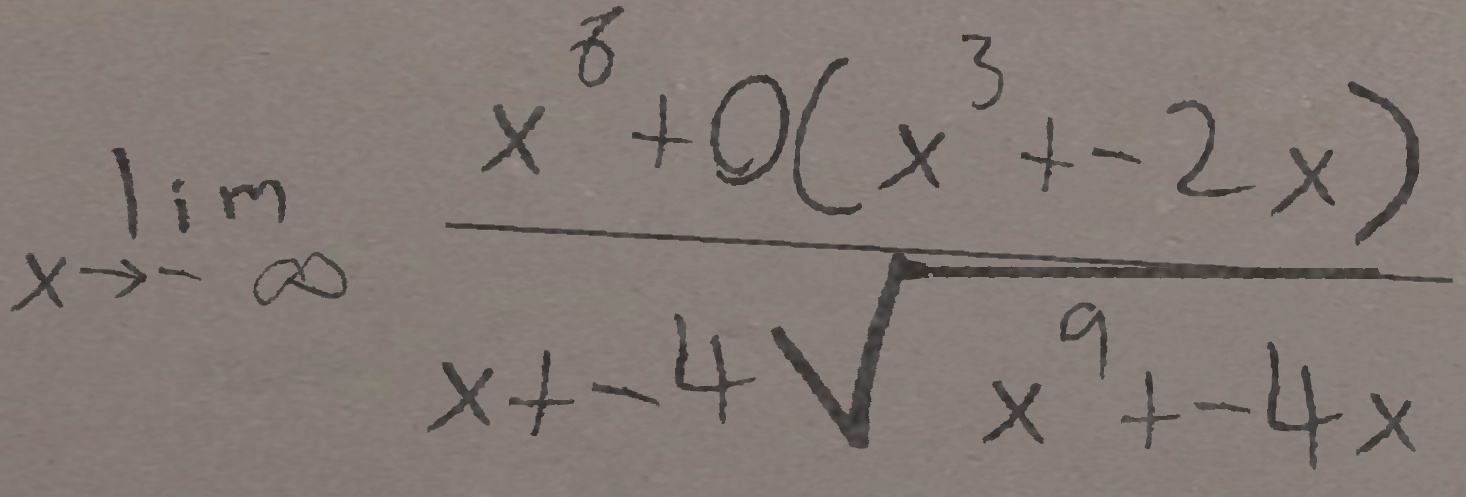

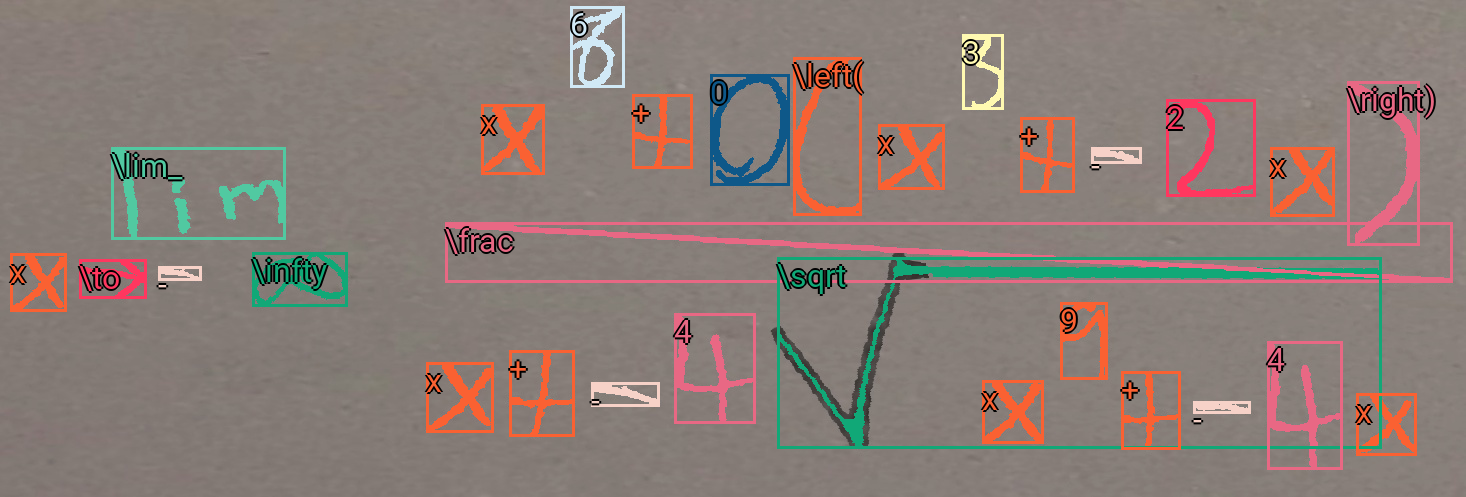

In [36]:
display(Image.open(f"{extras_path}/single_example/example_img.jpg"))
display(example_img)
# '\\lim_{p\\to\\pi/3^{-}}\\frac{\\sin^{3}{p}}{2\\frac{-5}{5p+\\left(-3\\pi\\right)^{2}}}'

In [37]:
# Code for segmenting and regenerating images

import os
import cv2
import numpy as np
import base64

def decode_png_mask(mask_str):
    mask_str = mask_str.strip().replace('\n', '')
    missing_padding = len(mask_str) % 4
    if missing_padding:
        mask_str += '=' * (4 - missing_padding)
    try:
        mask_bytes = base64.b64decode(mask_str)
    except Exception as e:
        print("Error decoding mask:", e)
        return None
    mask_array = np.frombuffer(mask_bytes, dtype = np.uint8)
    mask = cv2.imdecode(mask_array, cv2.IMREAD_GRAYSCALE)
    return mask


def process_sample(row, images_dir, output_dir):
    filename = row['filename']
    img_path = os.path.join(images_dir, filename)
    img = cv2.imread(img_path)
    if img is None:
        return
    width = row['width']
    height = row['height']
    xmins = row['xmins']
    xmaxs = row['xmaxs']
    ymins = row['ymins']
    ymaxs = row['ymaxs']
    # tokens = row['visible_latex_chars']
    labels = row['visible_latex_chars']
    masks = row['png_masks']
    for i in range(len(xmins)):
        x1 = int(xmins[i] * width)
        x2 = int(xmaxs[i] * width)
        y1 = int(ymins[i] * height)
        y2 = int(ymaxs[i] * height)
        seg = img[y1:y2, x1:x2]
        if masks and i < len(masks) and masks[i]:
            mask = decode_png_mask(masks[i])
            if mask is not None and mask.size > 0:
                try:
                    mask = cv2.resize(mask, (seg.shape[1], seg.shape[0]))
                    seg = cv2.bitwise_and(seg, seg, mask = mask)
                except Exception as e:
                    print(f"Error resizing/applying mask for segment {i} in {filename}: {e}")
            else:
                print(f"Warning: Decoded mask is empty for segment {i} in {filename}. Skipping mask.")
        seg_filename = f"{os.path.splitext(filename)[0]}_seg_{i}.png"
        cv2.imwrite(os.path.join(output_dir, seg_filename), seg)
        print(seg_filename, labels[i])

In [38]:
def locate_images(df):

    row_img_data = []

    for row in df.rdd.toLocalIterator():

        # directories = gg("archive/batch_*/background_images")

        image = row['filename']

        likely_image_path = [os.path.join(dir, image) for dir in images]

        existing_image = [img for img in likely_image_path if os.path.exists(img)][0]

        if existing_image:
            row_img_data.append([row, existing_image])
        else:
            continue

    return row_img_data

In [39]:
def decode_png_masks(mask_str):
    mask_str = mask_str.strip().replace("\n", "")
    missing_padding = len(mask_str) % 4
    if missing_padding:
        mask_str += "=" * (4 - missing_padding)
    try:
        mask_decoded = base64.b64decode(mask_str)
    except Exception as e:
        print(f"Error decoding mask: {e}")
        return None
    mask_array = np.frombuffer(mask_decoded, dtype = np.uint8)
    mask = cv2.imdecode(mask_array, cv2.IMREAD_GRAYSCALE)
    return mask

In [40]:
def process_image(row, images_dir, output_dir = "pre_training"):
    filename = row['filename']
    # img_path = os.path.join(images_dir, filename)
    img = cv2.imread(images_dir)

    if img is None:
        return

    xmins = row['xmins_raw']
    xmaxs = row['xmaxs_raw']
    ymins = row['ymins_raw']
    ymaxs = row['ymaxs_raw']
    labels = row['visible_latex_chars']
    masks = row['png_masks']

    print("Output path exists") if os.path.exists(output_dir) else os.mkdir(output_dir)

    for i in range(len(xmins)):
        x1, y1, x2, y2 = xmins[i], ymins[i], xmaxs[i], ymaxs[i]
        seg = img[y1:y2, x1:x2]

        if masks and i < len(masks) and masks[i]:
            mask = decode_png_masks(masks[i])
            if mask != None and mask.size > 0:
                try:
                    mask = cv2.resize(mask, (seg.shape[1], seg.shape[0]))
                    seg = cv2.bitwise_and(seg, seg, mask = mask)
                except Exception as e:
                    print(f"Error resizing mask for segment {i} in {filename}: {e}")
            else:
                print(f"Warning: Decoded mask is empty for segment {i} in {filename}. Skipping mask")

        stripped_label = str.strip(labels[i], '/\_')
        if len(stripped_label) == 0:
            stripped_label = "divide"
        label_path = os.path.join(output_dir, stripped_label)
        count = len(gg(f"{label_path}/*"))
        seg_filename = f"{os.path.join(label_path, stripped_label)}_{count + 1}.png"

        if os.path.exists(label_path):
            cv2.imwrite(seg_filename, seg)
        else:
            os.mkdir(label_path)
            cv2.imwrite(seg_filename, seg)

In [54]:
filtered_image_props = image_props.select("filename", "xmins_raw", "xmaxs_raw", "ymins_raw", "ymaxs_raw", "visible_latex_chars", "png_masks")

In [59]:
first_row_df = filtered_image_props.limit(1)

In [61]:
# images_data = locate_images(filtered_image_props)
images_data = locate_images(first_row_df)

In [62]:
for row, image_dir in images_data:
    process_image(row, image_dir)

Error decoding mask: Invalid base64-encoded string: number of data characters (949) cannot be 1 more than a multiple of 4
Error decoding mask: Invalid base64-encoded string: number of data characters (1697) cannot be 1 more than a multiple of 4


In [44]:
images_dir = f"{images[0]}/background_images"
output_dir = "output_images"

os.makedirs(output_dir, exist_ok = True)

# rows = filtered_image_props.collect()

for row in filtered_image_props.rdd.toLocalIterator():
    process_sample(row.asDict(), images_dir, output_dir)

For each segment, there shoud be a predefined LaTeX label that is normally printed on the bounding box. We can use this to classify said segment that has been extracted into its respective folder.

Use os.path.join to merge filename and directory to use the filename in the spark df to locate said image.

In [46]:
# import os
# import cv2
# import json
# import numpy as np
# import base64

# def decode_png_mask(mask_str):
#     mask_bytes = base64.b64decode(mask_str)
#     mask_array = np.frombuffer(mask_bytes, np.uint8)
#     mask = cv2.imdecode(mask_array, cv2.IMREAD_GRAYSCALE)
#     return mask

# def segment_sample(sample, images_dir, output_dir):
#     img_path = os.path.join(images_dir, sample['filename'])
#     img = cv2.imread(img_path)
#     if img is None:
#         return []
#     img_data = sample['image_data']
#     xmins = img_data['xmins']
#     xmaxs = img_data['xmaxs']
#     ymins = img_data['ymins']
#     ymaxs = img_data['ymins']
#     tokens = sample.get('visible_latex_chars', [])
#     masks = img_data.get('png_masks', [])
#     segments = []
#     for i in range(len(tokens)):
#         x1 = int(xmins[i])
#         x2 = int(xmaxs[i])
#         y1 = int(ymins[i])
#         y2 = int(ymaxs[i])
#         seg = img[y1:y2, x1:x2]
#         if masks and i < len(masks) and masks[i]:
#             mask = decode_png_mask(masks[i])
#             mask = cv2.resize(mask, (seg.shape[1], seg.shape[0]))
#             seg = cv2.bitwise_and(seg, seg, mask=mask)
#         seg_filename = f"{os.path.splitext(sample['filename'])[0]}_seg_{i}.png"
#         cv2.imwrite(os.path.join(output_dir, seg_filename), seg)
#         segments.append((seg, tokens[i]))
#     return segments

# with open('metadata.json', 'r') as f:
#     data = json.load(f)

# images_dir = 'path/to/images'
# output_dir = 'path/to/segments'
# os.makedirs(output_dir, exist_ok=True)

# all_segments = []
# for sample in data:
#     segs = segment_sample(sample, images_dir, output_dir)
#     all_segments.extend(segs)


In [48]:
# import xml.etree.ElementTree as ET
# from PIL import Image, ImageDraw
# import matplotlib.pyplot as plt

# def parse_inkml(filename):
#     ns = {"ink": "http://www.w3.org/2003/InkML"}
#     tree = ET.parse(filename)
#     root = tree.getroot()
#     strokes = []
#     for trace in root.findall(".//ink:trace", ns):
#         trace_text = trace.text.strip()
#         points = trace_text.split()
#         stroke = []
#         for pt in points:
#             parts = pt.split(',')
#             if len(parts) != 2:
#                 continue
#             try:
#                 x, y = map(float, parts)
#                 stroke.append((x, y))
#             except Exception as e:
#                 print(f"Error converting {pt}: {e}")
#         if stroke:
#             strokes.append(stroke)
#     return strokes

# filename = "mathwriting/synthetic/0a0b6ce511fa5ba5.inkml"
# strokes = parse_inkml(filename)

# if not strokes:
#     print("No strokes found.")
# else:
#     xs = [x for stroke in strokes for (x, y) in stroke]
#     ys = [y for stroke in strokes for (x, y) in stroke]
#     min_x, max_x = min(xs), max(xs)
#     min_y, max_y = min(ys), max(ys)

#     padding = 10
#     img_width = int(max_x - min_x) + 2 * padding
#     img_height = int(max_y - min_y) + 2 * padding
#     img = Image.new("RGB", (img_width, img_height), "white")
#     draw = ImageDraw.Draw(img)

#     for stroke in strokes:
#         stroke_translated = [(x - min_x + padding, y - min_y + padding) for (x, y) in stroke]
#         draw.line(stroke_translated, fill="black", width=2)

#     img.show()

#     plt.figure(figsize=(6, 6))
#     plt.imshow(img)
#     plt.axis('off')
#     plt.title("InkML Handwritten Expression Visualization")
#     plt.show()

In [49]:
# import os

# directory = "pre_training/slash"

# for filename in os.listdir(directory):
#     if filename.startswith("_") and filename.endswith(".jpg"):
#         num_part = filename[1:].split(".")[0]
#         new_name = f"slash{num_part}.jpg"

#         old_path = os.path.join(directory, filename)
#         new_path = os.path.join(directory, new_name)

#         os.rename(old_path, new_path)
#         print(f"Renamed: {filename} -> {new_name}")

# print("Renaming complete!")

In [51]:
# import os
# import tensorflow as tf
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# img_height, img_width = 256, 256
# batch_size = 32

# train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# train_generator = train_datagen.flow_from_directory(
#     'pre_training',
#     target_size=(img_height, img_width),
#     batch_size=batch_size,
#     class_mode='categorical',
#     subset='training'
# )

# validation_generator = train_datagen.flow_from_directory(
#     'pre_training',
#     target_size=(img_height, img_width),
#     batch_size=batch_size,
#     class_mode='categorical',
#     subset='validation'
# )

# model = Sequential([
#     Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
#     MaxPooling2D((2, 2)),
#     Conv2D(64, (3, 3), activation='relu'),
#     MaxPooling2D((2, 2)),
#     Conv2D(128, (3, 3), activation='relu'),
#     MaxPooling2D((2, 2)),
#     Flatten(),
#     Dense(128, activation='relu'),
#     Dropout(0.5),
#     Dense(train_generator.num_classes, activation='softmax')
# ])

# model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# epochs = 100
# # history = model.fit(
# #     train_generator,
# #     steps_per_epoch=train_generator.samples // batch_size,
# #     validation_data=validation_generator,
# #     validation_steps=validation_generator.samples // batch_size,
# #     epochs=epochs
# # )

# model.save('cnn_model.h5')

# print('Training complete')

In [52]:
# import os
# import torch
# from torchvision import datasets, transforms
# from torch.utils.data import DataLoader

# import torch.nn as nn
# import torch.optim as optim


# class CNNModel(nn.Module):
#     def __init__(self):
#         super(CNNModel, self).__init__()
#         self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
#         self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
#         self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
#         self.fc1 = nn.Linear(64 * 64 * 64, 128)
#         self.fc2 = nn.Linear(128, 10)

#     def forward(self, x):
#         x = self.pool(F.relu(self.conv1(x)))
#         x = self.pool(F.relu(self.conv2(x)))
#         x = x.view(-1, 64 * 64 * 64)
#         x = F.relu(self.fc1(x))
#         x = self.fc2(x)
#         return x

# transform = transforms.Compose([
#     transforms.Resize((256, 256)),
#     transforms.ToTensor(),
#     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
# ])

# train_dataset = datasets.ImageFolder(root='pre_training', transform=transform)
# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# model = CNNModel()
# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=0.001)

# num_epochs = 10
# # for epoch in range(num_epochs):
# #     running_loss = 0.0
# #     for i, (inputs, labels) in enumerate(train_loader):
# #         optimizer.zero_grad()
# #         outputs = model(inputs)
# #         loss = criterion(outputs, labels)
# #         loss.backward()
# #         optimizer.step()
# #         running_loss += loss.item()
# #         if i % 10 == 9:
# #             print(f'Epoch [{epoch + 1}/{num_epochs}], Step [{i + 1}/{len(train_loader)}], Loss: {running_loss / 10:.4f}')
# #             running_loss = 0.0

# print('Training complete')